# Self Attention

## Data Preparation

1) padding <pad> for making all sequences of same length in batch.  
2) unknown <unk> to handle any rare or out of vocabulary words the model might encounter during inference

In [1]:
import math
import os
import re 
import urllib.request
from collections import Counter
from typing import Callable, Dict, List, Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn   
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

import torch.optim as optim


/home/mfaizan/personal/FROM_SCRATCH_ML/from_scratch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# Tiny toy dataset
sentences = """
the dog chased the cat
the cat chased the mouse
the dog ran fast
the mouse ran fast
the cat lay down
"""

## build vocab
tokens = sentences.split()
vocab = ['<pad>','<unk>'] + sorted(set(tokens))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for i, w in enumerate(vocab)}
print(f"Vocab size: {len(vocab)}")

Vocab size: 11


In [3]:
## Tokenizer
## convert into root letters or basic unit from the word 
## and mapping tokens to indices

## Steps
#1) Coverting everything to lower case consistency
#2) Removing punctuation to focus on word embeddings
#3) Splitting on Whitespace and word boundaries


## Tokenizer

In [4]:
class SimpleTokenizer:
    """
    Splits on whitespace and lowercases, with optional regex for real word tokens.
    """

    def __init__(self):
        pass

    def __call__(self, text):
        text = text.lower()
        tokens = re.findall(r'\b\w+\b', text)
        return tokens




In [5]:
tokenizer  = SimpleTokenizer()
tokens = tokenizer("The Dog chased the Cat.")
print(tokens)

['the', 'dog', 'chased', 'the', 'cat']


## Building the Vocabulary

In [6]:
def build_vocab(sentences, tokenizer, min_freq = 1):

    counter = Counter()

    ## dictionary for word count
    for sent in sentences:
        counter.update(tokenizer(sent))

    ## creating vocab
    vocab = [w for w,c in counter.items() if c>=min_freq]
    vocab+=['<pad>','<unk>']

    ## word to index
    word2idx = {w: i for i, w in enumerate(vocab)}

    ## index to word
    idx2word = {i:w for i, w in enumerate(vocab)}

    return vocab, word2idx, idx2word


In [7]:
# Using our sample sentences and tokenizer
sentences = [
    "the dog chased the cat",
    "the cat chased the mouse",
    "the dog ran fast",
    "the mouse ran fast",
    "the cat lay down"
]
tokenizer = SimpleTokenizer()
vocab, word2idx, idx2word = build_vocab(sentences, tokenizer, min_freq=1)
print(f"Vocab: {vocab}")
print(f"Word to Index: {word2idx}")
print(f"Index to Word: {idx2word}")

Vocab: ['the', 'dog', 'chased', 'cat', 'mouse', 'ran', 'fast', 'lay', 'down', '<pad>', '<unk>']
Word to Index: {'the': 0, 'dog': 1, 'chased': 2, 'cat': 3, 'mouse': 4, 'ran': 5, 'fast': 6, 'lay': 7, 'down': 8, '<pad>': 9, '<unk>': 10}
Index to Word: {0: 'the', 1: 'dog', 2: 'chased', 3: 'cat', 4: 'mouse', 5: 'ran', 6: 'fast', 7: 'lay', 8: 'down', 9: '<pad>', 10: '<unk>'}


In [8]:
word = "cat"
idx = word2idx.get(word, word2idx['<unk>'])
print(f"Index of '{word}': {idx}")
print(f"Word for index {idx}: {idx2word[idx]}")

Index of 'cat': 3
Word for index 3: cat


## sliding Windows

**Predicting Next Word after Window**

In [9]:
## selecting fixed size window as input and train to predict the next word that follows the window in the sentence.
tokenizer = SimpleTokenizer()
vocab, word2idx, idx2word = build_vocab(sentences, tokenizer)

## 2
SEQ_LEN = 4

## 3
encoded_sentences = []
for sent in sentences:
    ## tokenizations
    tokens = tokenizer(sent)
    
    ## Map tokens to IDS
    ids = [word2idx.get(tok, word2idx['<unk>']) for tok in tokens]

    encoded_sentences.append(ids)

## 4 
inputs = []
targets = []
for ids in encoded_sentences:
    for i in range(len(ids)-SEQ_LEN):
        ## window length of SEQ_LEN
        window = ids[i:i+SEQ_LEN]

        ## Just next word after target
        target = ids[i+SEQ_LEN]

        inputs.append(window)
        targets.append(target)

## 5
for input , target in zip(inputs, targets):
    inp_words = [idx2word[i] for i in input]
    tgt_word = [idx2word[target]]

    print(f"Input: {inp_words} -> Target : {tgt_word}")



Input: ['the', 'dog', 'chased', 'the'] -> Target : ['cat']
Input: ['the', 'cat', 'chased', 'the'] -> Target : ['mouse']


## Turning the Data into a Pytorch Dataset 

In [10]:
class TinyDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = torch.tensor(inputs, dtype= torch.long)
        self.targets = torch.tensor(targets, dtype= torch.long)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
    
        return self.inputs[idx], self.targets[idx]


In [11]:
dataset = TinyDataset(inputs, targets)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

### Manual Self Attention Implementation

In [12]:
class ManualSelfAttention(nn.Module):
    
    def __init__(self,d):
        super().__init__()

        self.to_q  = nn.Linear(d, d, bias = False)
        self.to_k = nn.Linear(d, d, bias = False)
        self.to_v =nn.Linear(d, d, bias = False)

    def forward(self,x):
        ## query space
        Q = self.to_q(x)

        ## key space
        K = self.to_k(x)

        ## value space 
        V = self.to_v(x)

        ## Q@K.T/sqrt(embeddig size)

        ## Raw Score
        score = Q@K.transpose(-2, -1)/math.sqrt(Q.size(-1))

        ##  normalization using softmax
        attention_score = F.softmax(score, dim = -1)

        ## now creating contexted riched embeddings
        out = torch.matmul(attention_score, V)

        return out, attention_score

In [13]:
## Now visualize for the toy dataset
sentence = "the dog chased the cat"
tokens = tokenizer(sentence)

token_ids = [word2idx.get(tok, word2idx['<unk>']) for tok in tokens]
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

Tokens: ['the', 'dog', 'chased', 'the', 'cat']
Token IDs: [0, 1, 2, 0, 3]


In [14]:
embedding_dim = 2

## embedding 
embed = nn.Embedding(len(vocab), embedding_dim)
torch.manual_seed(42)
x = embed(torch.tensor(token_ids)).unsqueeze(0)  # Add batch dimension

print(f"Input Embeddings: {x}")

Input Embeddings: tensor([[[-0.3589, -1.3877],
         [-1.1997, -0.2538],
         [ 0.9268, -0.1464],
         [-0.3589, -1.3877],
         [ 0.2760,  0.5577]]], grad_fn=<UnsqueezeBackward0>)


In [15]:
attn_layer = ManualSelfAttention(embedding_dim)

# Put the input through self-attention
out, attn = attn_layer(x)

print("Attention weights:\n", attn[0].detach().numpy())
print("Output representations:\n", out[0].detach().numpy())

Attention weights:
 [[0.24337982 0.12567838 0.23675244 0.24337982 0.1508096 ]
 [0.20856103 0.18014123 0.21154396 0.20856103 0.19119276]
 [0.20473464 0.19515118 0.20082349 0.20473464 0.19455604]
 [0.24337982 0.12567838 0.23675244 0.24337982 0.1508096 ]
 [0.18086356 0.2365909  0.18247294 0.18086356 0.21920896]]
Output representations:
 [[ 0.30113494 -0.12666821]
 [ 0.21181306 -0.14454651]
 [ 0.19136526 -0.15810539]
 [ 0.30113494 -0.12666821]
 [ 0.12725838 -0.17485031]]


In [16]:
print("Tokens:", tokens)
print("Token IDs:", token_ids)
print("idx2word:", idx2word)

print("\nAttention Weights Matrix (rows: query token, columns: attended token):")
for i, w in enumerate(tokens):
    row = ["{:.2f}".format(a) for a in attn[0, i].detach().cpu().numpy()]
    print(f"{w:>8} attends to -> {row}")

Tokens: ['the', 'dog', 'chased', 'the', 'cat']
Token IDs: [0, 1, 2, 0, 3]
idx2word: {0: 'the', 1: 'dog', 2: 'chased', 3: 'cat', 4: 'mouse', 5: 'ran', 6: 'fast', 7: 'lay', 8: 'down', 9: '<pad>', 10: '<unk>'}

Attention Weights Matrix (rows: query token, columns: attended token):
     the attends to -> ['0.24', '0.13', '0.24', '0.24', '0.15']
     dog attends to -> ['0.21', '0.18', '0.21', '0.21', '0.19']
  chased attends to -> ['0.20', '0.20', '0.20', '0.20', '0.19']
     the attends to -> ['0.24', '0.13', '0.24', '0.24', '0.15']
     cat attends to -> ['0.18', '0.24', '0.18', '0.18', '0.22']


### Going to give Ordering to the words
**Could be given by two ways learned Positional Embeddings , fixed Mathematical function(Sinusodial encodings)sine and cosine waves at different frequencie to Represent the Positions.**  

- Here we will apply learned Positional Encoding
- It require Embedding dimension and Length of the Voculabulary


In [17]:
class SelfAttnWithPositionalEmbedding(nn.Module):

    def __init__(self, vocab_size, seq_len, emb_dim):
        super().__init__()

        ## tokens embeddings
        self.tok_embeddings = nn.Embedding(vocab_size, emb_dim)

        ## pos_embeddings 
        self.pos_embeddings = nn.Embedding(vocab_size, emb_dim)

        ## attention 
        self.attention = ManualSelfAttention(emb_dim)

        ## linear layer for predicting next token
        self.fc = nn.Linear(emb_dim, vocab_size)

        self.seq_len = seq_len

    def forward(self, token_ids):
        batch_size, seq_len = token_ids.shape
        # Generate a range of indices representing the position of each token in the sequence
        positions = torch.arange(self.seq_len, device=token_ids.device).unsqueeze(0).expand(batch_size,seq_len)
        
        ## token embediings 
        tok_embeddings = self.tok_embeddings(token_ids)

        ## pos_embeddings
        pos_embeddings = self.pos_embeddings(positions)

        ## input embeddings
        input_embeddings = tok_embeddings + pos_embeddings

        ## context aware embeddinsg
        attention_embeddings, attention_score = self.attention(input_embeddings)

        ## extract the hidden representation corresponding to the final token in the sequence
        last_hidden = attention_embeddings[:,-1, :]

        logits = self.fc(last_hidden)

        return logits, attention_score
        


In [18]:
x = torch.tensor([[[ 0.12, -0.55,  0.33,  0.10],
                   [-0.44,  0.91, -0.12, -0.77],
                   [ 0.48,  0.02,  0.05,  0.39],
                   [ 0.12, -0.55,  0.33,  0.10],
                   [-0.30,  0.14, -0.70,  0.81]]])  # [1, 5, 4]

attn = ManualSelfAttention(d=4)
out, attn_weights = attn(x)

print("Attention weights matrix (attn_weights):\n", attn_weights[0].detach().numpy())
print('\nExplanation:')
print("Each row i shows the attention distribution (softmaxed) over all positions in the input sequence,")
print("when computing the updated representation for token i. Rows sum to 1.\n")

print("Self-attention output (out):\n", out[0].detach().numpy())
print('\nExplanation:')
print("Each row is the new vector for input position i, computed as a weighted sum")
print("of the original value vectors, using that row from the attention weights matrix as weights.\n")

Attention weights matrix (attn_weights):
 [[0.2045003  0.19939555 0.19791807 0.2045003  0.19368581]
 [0.20429866 0.18604459 0.19986285 0.20429866 0.2054951 ]
 [0.20075151 0.20953414 0.19840634 0.20075151 0.1905564 ]
 [0.2045003  0.19939555 0.19791807 0.2045003  0.19368581]
 [0.1752569  0.2248506  0.20471737 0.1752569  0.2199183 ]]

Explanation:
Each row i shows the attention distribution (softmaxed) over all positions in the input sequence,
when computing the updated representation for token i. Rows sum to 1.

Self-attention output (out):
 [[ 0.00884607 -0.01287259  0.01861886 -0.04904138]
 [ 0.01191892 -0.00959278  0.01647992 -0.05837096]
 [ 0.00341012 -0.0150374   0.02305589 -0.04652082]
 [ 0.00884607 -0.01287259  0.01861886 -0.04904138]
 [-0.02247121 -0.01640684  0.0455     -0.06841484]]

Explanation:
Each row is the new vector for input position i, computed as a weighted sum
of the original value vectors, using that row from the attention weights matrix as weights.



In [19]:
## initialing the model
## selecting real example form dataset
## Run model to get attention weights and visualize them


#### Helper function for plotting attention weights

In [20]:
def plot_attention(attn_weights, tokens, title="Self-Attention Map"):
    """
    Visualizes the self-attention weights for a sequence using a heatmap.
    
    Args:
        attn_weights: A tensor of attention scores, usually of shape [batch, seq_len, seq_len].
        tokens: A list of strings representing the tokens for labeling the axes.
        title: A string to be used as the title of the generated plot.

    Returns:
        None. This function displays a plot directly.
    """
    # Extract attention weights for the first batch entry and transfer to host memory
    aw = attn_weights[0].detach().cpu().numpy()
    # Initialize the figure with dimensions scaled to the number of tokens
    plt.figure(figsize=(1.2 * len(tokens), 5))
    # Render the attention matrix as a heatmap with a blue color gradient
    plt.imshow(aw, cmap='Blues')
    # Assign token strings to the horizontal axis with a specific rotation for readability
    plt.xticks(range(len(tokens)), tokens, rotation=45)
    # Assign token strings to the vertical axis
    plt.yticks(range(len(tokens)), tokens)
    # Include a legend showing the mapping of colors to attention intensity
    plt.colorbar()
    # Set the provided title for the visualization
    plt.title(title)
    # Adjust layout parameters to prevent label clipping
    plt.tight_layout()
    # Render the final visualization to the screen
    plt.show()

In [21]:
vocab_ize = len(vocab)
embed_dim = 8
model = SelfAttnWithPositionalEmbedding(vocab_size=vocab_ize, seq_len=SEQ_LEN, emb_dim=embed_dim)

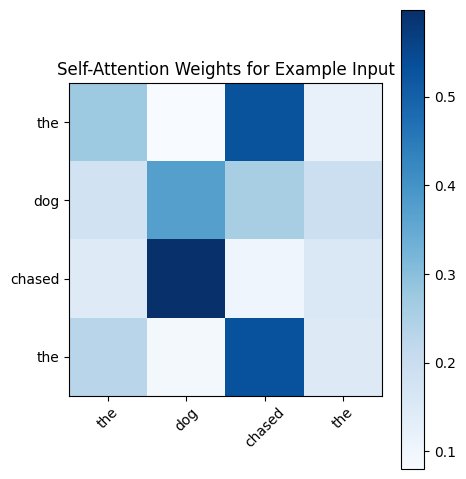

In [22]:
ex_ix = 0
input_ids = inputs[ex_ix]
tokens = [idx2word[i] for i in input_ids]

model.eval()
x_example = torch.tensor([input_ids], dtype=torch.long)  # Add batch dimension
with torch.no_grad():
    logits, attn_weights = model(x_example) 

##plot attention
plot_attention(attn_weights, tokens, title="Self-Attention Weights for Example Input")

### The Training Loop

In [23]:
def train_model(model,loader, loss_fn, optimize, epochs = 20, device = 'cpu'):

    model.to(device)
    for epoch in range(epochs):
        model.train()

        total_loss = 0

        with tqdm(loader, desc = f"Epoch {epoch+1}/{epochs}") as pbar:
            for xb, yb in pbar:
                xb, yb = xb.to(device), yb.to(device)

                optimizer.zero_grad()

                logits, _ = model(xb)

                loss = loss_fn(logits, yb)
                
                ## gradient calculated
                loss.backward() 

                ## optimization
                optimizer.step()

                total_loss +=loss.item() * xb.size(0)

                pbar.set_postfix(loss = loss.item())
        
        avg_loss = total_loss/ len(loader.dataset)

        print(f"Epoch {epoch+1}: avg_loss =  {avg_loss:.4f}")

In [24]:
def train_model(model,loader, loss_fn, optimizer, epochs = 20, device = 'cpu'):

    model.to(device)
    for epoch in range(epochs):
        model.train()

        total_loss = 0

        with tqdm(loader, desc = f"Epoch {epoch+1}/{epochs}") as pbar:
            for xb, yb in pbar:
                xb, yb = xb.to(device), yb.to(device)

                optimizer.zero_grad()

                logits, _ = model(xb)

                loss = loss_fn(logits, yb)
                
                ## gradient calculated
                loss.backward() 

                ## optimization
                optimizer.step()

                total_loss +=loss.item() * xb.size(0)

                pbar.set_postfix(loss = loss.item())
        
        avg_loss = total_loss/ len(loader.dataset)



        print(f"Epoch {epoch+1}: avg_loss =  {avg_loss:.4f}")


In [25]:
len(loader)

1

In [26]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_fn = nn.CrossEntropyLoss()

device = 'cuda' if torch.cuda.is_available() else 'cpu'

train_model(model,loader, loss_fn, optimizer, epochs=200, device=device)

Epoch 1/200: 100%|██████████| 1/1 [00:00<00:00, 74.66it/s, loss=2.38]


Epoch 1: avg_loss =  2.3817


Epoch 2/200: 100%|██████████| 1/1 [00:00<00:00, 79.67it/s, loss=2.37]


Epoch 2: avg_loss =  2.3724


Epoch 3/200: 100%|██████████| 1/1 [00:00<00:00, 69.04it/s, loss=2.36]


...

Epoch 198: avg_loss =  0.7088


Epoch 199/200: 100%|██████████| 1/1 [00:00<00:00, 563.67it/s, loss=0.709]


Epoch 199: avg_loss =  0.7086


Epoch 200/200: 100%|██████████| 1/1 [00:00<00:00, 558.79it/s, loss=0.708]

Epoch 200: avg_loss =  0.7084


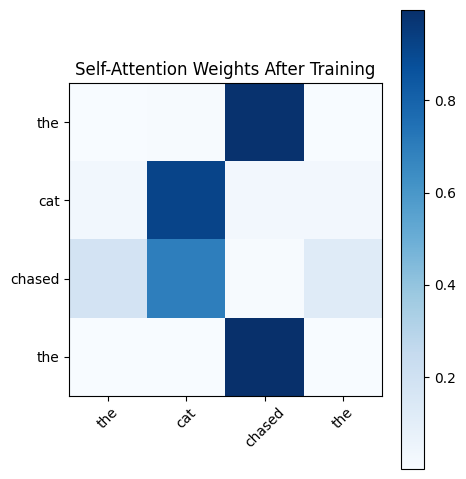

In [27]:
ex_ix = 1
input_ids = inputs[ex_ix]
tokens = [idx2word[i] for i in input_ids]
model.eval()
x_example = torch.tensor([input_ids], dtype=torch.long)  # Add batch dimension
with torch.no_grad():
    logits, attn_weights = model(x_example) 

plot_attention(attn_weights, tokens, title="Self-Attention Weights After Training")

In [28]:
idx2word[logits.argmax(dim=-1).item()]

'cat'

In [29]:
tokens

['the', 'cat', 'chased', 'the']

In [30]:
## generating text word
def generete_next_words(model, sentence, tokenizer, word2idx, idx2word,max_tokens = 5, seq_len =4, device = 'cpu'):

    model.eval()

    tokens = tokenizer(sentence)

    ## Extract the most recent rokens to fit the models context length 
    for _ in range(max_tokens):
        if len(tokens)>=seq_len:
            window = tokens[-seq_len:]
        else:
            window = ['<pad>']*(seq_len-len(tokens)) + tokens

        input_ids = torch.tensor([[word2idx.get(w, word2idx['<unk>']) for w in window]], dtype = torch.long).to(device)

        with torch.no_grad():
            logits, _ = model(input_ids)

            next_id = logits.argmax(dim = -1).item()
        
        next_word = idx2word[next_id]

        tokens.append(next_word)

    return tokens
    
    

In [31]:
sentence = "the dog chased the"
output  = generete_next_words(model, sentence, tokenizer, word2idx, idx2word, max_tokens = 1, seq_len =4, device = device)    

In [32]:
output

['the', 'dog', 'chased', 'the', 'cat']

In [33]:
print("Generated sequence:", " ".join(output))

Generated sequence: the dog chased the cat


In [34]:
## Data Preparation

url ="https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
filename = "shakespeare.txt"

if os.path.exists(filename):
    print(f"{filename} already exists. Skipping download.\n")

else:
    print(f"Downloading {filename} from {url}...")
    urllib.request.urlretrieve(url, filename)
    print("Download complete.\n")

shakespeare.txt already exists. Skipping download.



In [35]:
f = open(filename, 'r', encoding='utf-8')
text = f.read()
f.close()

In [36]:
print(text[:300])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [37]:
class ShakespeareTokenizer:

    def __call__(self, text):

        # subsitute new line character with a identifiable string toke
        text = text.replace('\n','<nl>')

        ##Extract word characters, possesives, special tokens and symbols using regex

        return re.findall(r"\w+(?:'\w+)?|<nl>|[^\w\s]", text)

In [38]:
## tokenizer initiation
tokenizer = ShakespeareTokenizer()

vocab, word2idx, idx2word = build_vocab([text], tokenizer, min_freq=1)
print(f"Vocab size: {len(vocab)}")

print("First 30 tokens in vocab:", vocab[:30])


Vocab size: 14300
First 30 tokens in vocab: ['First', 'Citizen', ':', '<nl>', 'Before', 'we', 'proceed', 'any', 'further', ',', 'hear', 'me', 'speak', '.', 'All', 'Speak', 'You', 'are', 'all', 'resolved', 'rather', 'to', 'die', 'than', 'famish', '?', 'Resolved', 'you', 'know', 'Caius']


### creating dataset for shakespeare text
### 25 length window and target

In [39]:
SEQ_LEN = 25
tokens = tokenizer(text)
inputs = []
targets = []

for i in range(len(tokens)-SEQ_LEN):
    window = tokens[i:i+SEQ_LEN]
    target = tokens[i+SEQ_LEN]
    input_ids = [word2idx.get(w, word2idx['<unk>']) for w in window]
    target_id = word2idx.get(target, word2idx['<unk>'])
    inputs.append(input_ids)
    targets.append(target_id)

print("Number of (input, target) pairs:", len(inputs))
print("Example input:",[idx2word[i] for i in inputs[0]])
print("Example target:",idx2word[targets[0]])

Number of (input, target) pairs: 293574
Example input: ['First', 'Citizen', ':', '<nl>', 'Before', 'we', 'proceed', 'any', 'further', ',', 'hear', 'me', 'speak', '.', '<nl>', '<nl>', 'All', ':', '<nl>', 'Speak', ',', 'speak', '.', '<nl>', '<nl>']
Example target: First


In [40]:
class ShakespeareDataset(Dataset):

    def __init__(self, inputs, targets):

        ## Maintain inputs
        self.inputs = torch.tensor(inputs, dtype = torch.long)

        ## target
        self.targets = torch.tensor(targets, dtype = torch.long)
    
    def __len__(self):

        return len(self.inputs)
    
    def __getitem__(self,idx):
        return self.inputs[idx], self.targets[idx]

In [41]:
dataset = ShakespeareDataset(inputs, targets)
loader = DataLoader(dataset, batch_size=128, shuffle=True)
vocab_size = len(vocab)

In [42]:

class SelfAttnWithMHA(nn.Module):


    def __init__(self, vocab_size, seq_len, embed_dim = 768, num_head = 12, dropout = 0.1):

        super().__init__()

        self.tok_embed = nn.Embedding(vocab_size, embed_dim)

        self.pos_embed = nn.Embedding(seq_len, embed_dim)

        self.attn = nn.MultiheadAttention(
            embed_dim = embed_dim, 
            num_heads = num_head,
            dropout = dropout,
            batch_first = True
        )

        self.fc = nn.Linear(embed_dim, vocab_size)

    def forward(self, token_ids):

        ## batch x inputs sequence
        batch_size, seq_len =token_ids.shape

        positions = torch.arange(seq_len, device  = token_ids.device).unsqueeze(0).expand(batch_size, seq_len) ## bxseq_len

        input_vecs = self.tok_embed(token_ids) + self.pos_embed(positions)


        ## for mha(query, key,value)
        attn_out, attn_w = self.attn(input_vecs, input_vecs, input_vecs, need_weights = True)

        last_hidden = attn_out[:,-1,:]

        logits = self.fc(last_hidden)

        return logits, attn_w



In [43]:
model = SelfAttnWithMHA(vocab_size = vocab_size, seq_len = SEQ_LEN)

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model.to(device)

torch.cuda.empty_cache()

In [44]:
# Example usage:
sentence = "to be or not"
output = generete_next_words(model, sentence, tokenizer, word2idx, idx2word, max_tokens=50, seq_len=SEQ_LEN, device=device)
print("Generated sequence:", " ".join(output))

Generated sequence: to be or not impiety prioress brew'd tods goad brew'd walked hate's Tie brew'd bended youthful brew'd walked hewn Tie weather Abides navel quaff'd navel Abides indirect Amity colour climate keep stripes viol loved Tickle Repair'd ague Tickle Amity arrow Barnardine hurried lodged We'll ascends sharps four sustain courageous RATCLIFF sincerity RATCLIFF Drop four


In [45]:
def train_model(model, loader, loss_fn, optimizer, epochs=10, device='cpu'):
    """
    Executes the training loop for a sequence model over a specified number of epochs.

    Args:
        model: The neural network model to be trained.
        loader: The DataLoader instance providing batches of training data.
        loss_fn: The loss function used to evaluate model performance.
        optimizer: The optimization algorithm used to update model weights.
        epochs: The total number of iterations over the complete dataset.
        device: The target hardware for computation (e.g., 'cpu' or 'cuda').
        vocab_size: Optional parameter specifying the size of the vocabulary.

    Returns:
        None. This function modifies the model and optimizer states in-place.
    """
    # Transfer the model to the specified hardware device
    model.to(device)
    # Begin iterating through the specified number of training cycles
    for epoch in range(epochs):
        # Configure the model for training mode to enable specific behaviors like dropout
        model.train()
        # Initialize an accumulator for the cumulative loss within the epoch
        total_loss = 0
        # Determine the total number of batches in the data loader
        n_batches = len(loader)
        # Iterate through data batches using a progress bar for monitoring
        with tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}") as pbar:
            for xb, yb in pbar:
                # Move the input and target tensors to the active device
                xb, yb = xb.to(device), yb.to(device)
                # Reset gradients of the model parameters to zero
                optimizer.zero_grad()
                # Perform the forward pass to obtain logits and attention weights
                logits, _ = model(xb)
                # Calculate the loss based on model predictions and actual targets
                loss = loss_fn(logits, yb)
                # Execute the backward pass to calculate gradients
                loss.backward()
                # Update model parameters based on the computed gradients
                optimizer.step()
                # Accumulate the weighted loss for the current batch
                total_loss += loss.item() * xb.size(0)
                # Display the loss value for the current batch in the progress bar
                pbar.set_postfix(loss=loss.item())

        # Calculate the mean loss across all samples in the dataset
        avg_loss = total_loss / len(loader.dataset)
        # Log the performance summary for the completed epoch
        print(f"Epoch {epoch+1:2d}: avg loss = {avg_loss:.4f}")

In [47]:
# EPOCHS =40
# # vocab_size = len(vocab)
# train_model(model, loader, loss_fn, optimizer, epochs=EPOCHS, device=device)


In [ ]:
# ## saving model
# torch.save(model.state_dict(), "self_attention_model_wmha.pth")

In [59]:
state_dict = torch.load(
    "/home/mfaizan/personal/FROM_SCRATCH_ML/Attention_from_Scratch/self_attention_model_wmha.pt",
    map_location=torch.device("cpu")  # or "cuda"
)

model.load_state_dict(state_dict)
model.eval()

SelfAttnWithMHA(
  (tok_embed): Embedding(14300, 768)
  (pos_embed): Embedding(25, 768)
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (fc): Linear(in_features=768, out_features=14300, bias=True)
)

In [60]:
class NextWordGenerator:

    def __init__(self, model, tokenizer, word2idx, idx2word, seq_len =6, device  = "cpu",pad_token = '<pad>', unk_token = '<unk>', nl_token = '<nl>'):

        self.model = model

        self.tokenizer =tokenizer 

        self.word2idx = word2idx

        self.idx2word = idx2word

        self.seq_len = seq_len

        self.device = device

        self.unk_token = unk_token

        self.pad_token = pad_token

        self.nl_token  = nl_token

    
    ## ensuring 25 length input tokens
    def _make_window(self, generated):

        if(len(generated)>=self.seq_len):
            return generated[-self.seq_len:]
        
        pad_count = self.seq_len - len(generated)

        return  [self.pad_token]*pad_count + generated

    

    def _encode(self, tokens):

        ids = [self.word2idx.get(t, self.word2idx.get(self.unk_token)) for t in tokens]
    
        return torch.tensor([ids], dtype = torch.long, device = self.device)

    def _decode_id(self,idx):

        return self.idx2word[idx]

    ## all the new line token will be "\n"
    def _postprocess(self, tokens):

        return [("\n" if t==self.nl_token else t) for t in tokens]

    def generate(self, sentence, *, max_tokens = 20, temperature = 1.0):
        
        if temperature<=0:
            raise ValueError("temperature must be > 0")

        self.model.eval()

        generated = list(self.tokenizer(sentence))

        with torch.no_grad():
            
            for _ in range (max_tokens):
                
                window  =self._make_window(generated)

                input_ids = self._encode(window)

                logits, _ = self.model(input_ids)

                logits = logits/temperature

                probs = torch.softmax(logits, dim = -1)

                next_id = torch.multinomial(probs, num_samples = 1).item()

                next_token = self._decode_id(next_id)

                generated.append(next_token)
        
        return self._postprocess(generated)

## generating texts

In [62]:
# Example usage:
generator = NextWordGenerator(
    model=model,
    tokenizer=tokenizer,
    word2idx=word2idx,
    idx2word=idx2word,
    seq_len=SEQ_LEN,
    device=device,
)

output = generator.generate("To be or not to", max_tokens=50, temperature=2.0)
print("Generated sequence:", " ".join(output))

Generated sequence: To be or not to we we we we we we we he any any at fortnight as No we we pikes as pikes shreds you than men hostile it we serves me Rome door TITUS One surfeits foremost ere done me have while work's hand than at we we done did we No price
